# 01 - Data Preparation & Cough Phase Segmentation

This notebook loads raw cough audio from the Coswara dataset and performs physiological phase segmentation:
- Inspiration
- Compression
- Expulsion (most relevant for COVID chaos)
- Glottis opening

We visualize the raw waveform, envelope, detected peaks, and final phase boundaries.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import hilbert, find_peaks
import pandas as pd

import sys
from pathlib import Path

from glob import glob

ROOT = Path().resolve().parent
sys.path.append(str(ROOT))


# Project root
# PROJECT_ROOT = ".."
DATA_RAW = os.path.join(ROOT, "data", "raw")

POS_DIR = os.path.join(ROOT, "data", "clean_audio","positive")
NEG_DIR = os.path.join(ROOT, "data", "clean_audio","negative")

pos_files = [os.path.join(POS_DIR, f) for f in os.listdir(POS_DIR) if f.endswith('cough-heavy.wav')][:5];
neg_files = [os.path.join(NEG_DIR, f) for f in os.listdir(NEG_DIR) if f.endswith('cough-heavy.wav')][:5];

# positive_cough_files = glob(os.path.join(DATA_RAW, "**", "cough-heavy.wav"), recursive=True);
# healthy_cough_files = glob(os.path.join(HEALTHY_DATA_RAW, "**","0EAAFsDWfTcrhktHy78LS6nf19G3_cough-heavy"), recursive=True);

if not pos_files:
    raise FileNotFoundError("No posotive files found!")

if not neg_files:
    raise FileNotFoundError("No healthy files found.");

EXAMPLE_POSITIVE = pos_files[0]
print("Using file:", EXAMPLE_POSITIVE)

# EXAMPLE_POSITIVE = "example_positive_cough.wav"
EXAMPLE_HEALTHY = neg_files[0]
print("using healthy file:",EXAMPLE_HEALTHY)

# cough_files = glob(os.path.join(DATA_RAW, "**", "cough-heavy.wav"), recursive=True);

# if not cough_files:
#     raise FileNotFoundError("No cough-heavy.wav files found!")

# EXAMPLE_POSITIVE = cough_files[0]
# print("Using file:", EXAMPLE_POSITIVE)

# Example: Adjust these to your actual file names from Coswara
# EXAMPLE_POSITIVE = "example_positive_cough.wav"  # Replace with real filename
# EXAMPLE_HEALTHY = "example_healthy_cough.wav"    # Replace with real filename

Using file: E:\SLIIT\Year_4\Semester_1\Research Project\RP-Project01\data\clean_audio\positive\1e8i6Q47ewbzrTiKqIeOLEvPv2Z2_cough-heavy.wav
using healthy file: E:\SLIIT\Year_4\Semester_1\Research Project\RP-Project01\data\clean_audio\negative\01OCEf1yB4czsq8ygRoT51s96Ba2_cough-heavy.wav


In [2]:
def load_audio(file_path):
    sr, audio = wavfile.read(file_path)
    audio = audio.astype(np.float32)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)  # Stereo to mono
    audio = audio / np.max(np.abs(audio))
    return audio, sr

def plot_waveform_with_phases(audio, sr, phases, title="Cough Waveform with Phases"):
    time = np.linspace(0, len(audio)/sr, len(audio))
    envelope = np.abs(hilbert(audio))
    
    plt.figure(figsize=(14, 6))
    plt.plot(time, audio, label="Waveform", alpha=0.7)
    plt.plot(time, envelope, label="Envelope", color="orange", linewidth=2)
    
    colors = ["green", "blue", "red", "purple"]
    labels = ["Inspiration", "Compression", "Expulsion", "Glottis"]
    starts = [0]
    for phase in ["inspiration", "compression", "expulsion", "glottis"]:
        segment = phases[phase]
        end_idx = starts[-1] + len(segment)
        plt.axvspan(time[starts[-1]], time[end_idx-1], alpha=0.3, color=colors.pop(0), label=labels.pop(0))
        starts.append(end_idx)
    
    plt.title(title, fontsize=16)
    plt.xlabel("Time (s)")
    plt.ylabel("Normalized Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def segment_phases(audio, sr, plot=True):
    analytic_signal = hilbert(audio)
    envelope = np.abs(analytic_signal)
    envelope /= np.max(envelope)
    
    peaks, _ = find_peaks(envelope, height=0.15, distance=sr*0.1)
    
    if len(peaks) < 3:
        print("Warning: Insufficient peaks detected. Using fallback.")
        peaks = np.argsort(envelope)[-4:][::-1]
    
    insp_end = peaks[0] if len(peaks) > 0 else int(0.3 * len(audio))
    comp_end = peaks[1] if len(peaks) > 1 else int(0.6 * len(audio))
    exp_end = peaks[-1] if len(peaks) > 2 else int(0.9 * len(audio))
    
    phases = {
        'inspiration': audio[0:insp_end],
        'compression': audio[insp_end:comp_end],
        'expulsion': audio[comp_end:exp_end],
        'glottis': audio[exp_end:]
    }
    
    if plot:
        plot_waveform_with_phases(audio, sr, phases)
    
    return phases

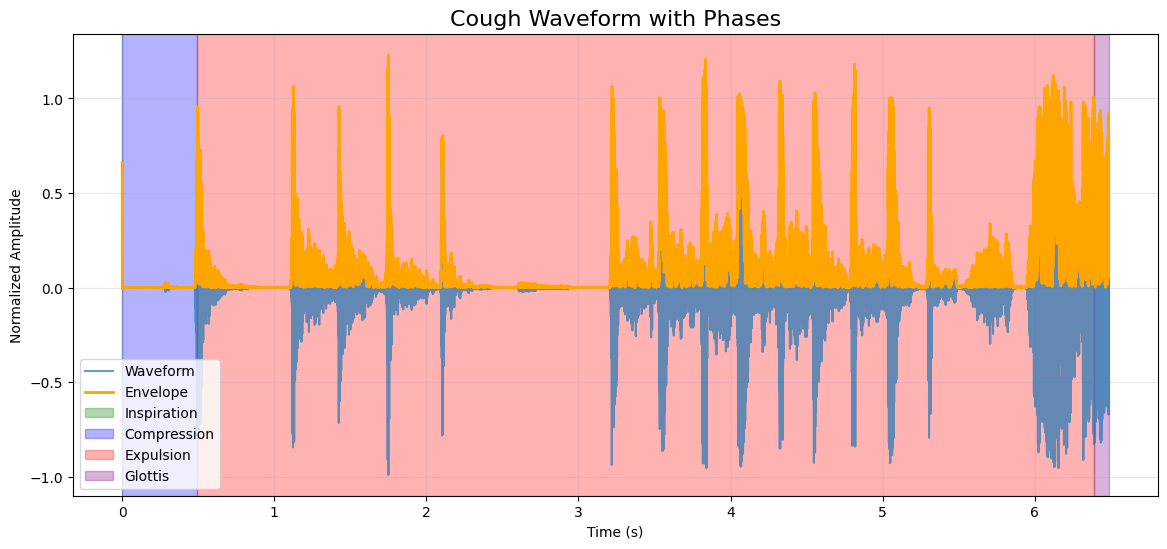

In [3]:
# Load and visualize a COVID-positive cough
audio_pos, sr_pos = load_audio(os.path.join(DATA_RAW, EXAMPLE_POSITIVE))
phases_pos = segment_phases(audio_pos, sr_pos, plot=True)

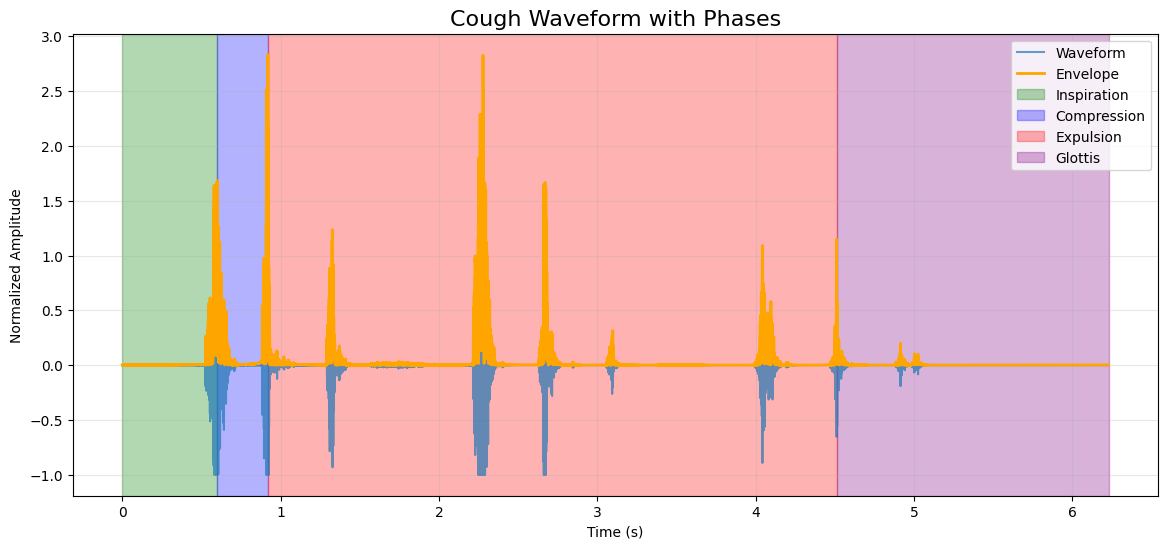

In [4]:
# Load and visualize a healthy cough
audio_healthy, sr_healthy = load_audio(os.path.join(DATA_RAW, EXAMPLE_HEALTHY))
phases_healthy = segment_phases(audio_healthy, sr_healthy, plot=True)

### Observation
Note the longer, more irregular **expulsion phase** in the COVID-positive sample — this is where chaos signatures are expected to be strongest due to lung fibrosis-induced turbulent airflow.